# Implementación de un MLP(Perceptron multi capa) para la aprobación de prestamos

Este modelo busca predecir la aprobación de préstamos basándose en diferentes entradas. El problema simula un escenario donde las relaciones entre las variables (predictoras y objetivas) no son linealmente separables.

In [2]:
# importacion de bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
# Carga de conjunto de datos
ruta = "data/loan_dataset.csv"
df = pd.read_csv(ruta)
df.shape

(1000, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Ingreso mensual           1000 non-null   float64
 1   Historial crediticio      1000 non-null   int64  
 2   Edad                      1000 non-null   int64  
 3   Número de deudas activas  1000 non-null   int64  
 4   Relación cuota/ingreso    1000 non-null   float64
 5   Tiempo en trabajo actual  1000 non-null   float64
 6   Aprobación                1000 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 54.8 KB


In [5]:
# Estadísticas descriptivas del conjunto de datos
df.describe()

,Ingreso mensual,Historial crediticio,Edad,Número de deudas activas,Relación cuota/ingreso,Tiempo en trabajo actual,Aprobación
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,8057.996167,578.66000,46.565000,4.514000,0.367823,14.914854,0.623000
std,2937.647815,156.81755,16.264695,2.870199,0.185537,8.664665,0.484877
min,-1723.802020,300.00000,18.000000,0.000000,0.050020,0.006811,0.000000
25%,6057.229084,445.75000,33.000000,2.000000,0.206308,7.666923,0.000000
50%,8075.901837,580.50000,47.000000,5.000000,0.365299,14.438659,1.000000
75%,9943.831626,715.00000,61.000000,7.000000,0.524200,22.471942,1.000000
max,19558.194472,849.00000,74.000000,9.000000,0.699713,29.963788,1.000000


In [6]:
df.head()

,Ingreso mensual,Historial crediticio,Edad,Número de deudas activas,Relación cuota/ingreso,Tiempo en trabajo actual,Aprobación
0,9490.142459,727,68,3,0.347910,24.071881,1
1,7585.207096,604,55,4,0.278293,25.842541,1
2,9943.065614,616,37,9,0.110955,4.119001,1
3,12569.089569,308,74,4,0.365985,28.571603,1
4,7297.539876,372,46,7,0.648481,9.864679,0


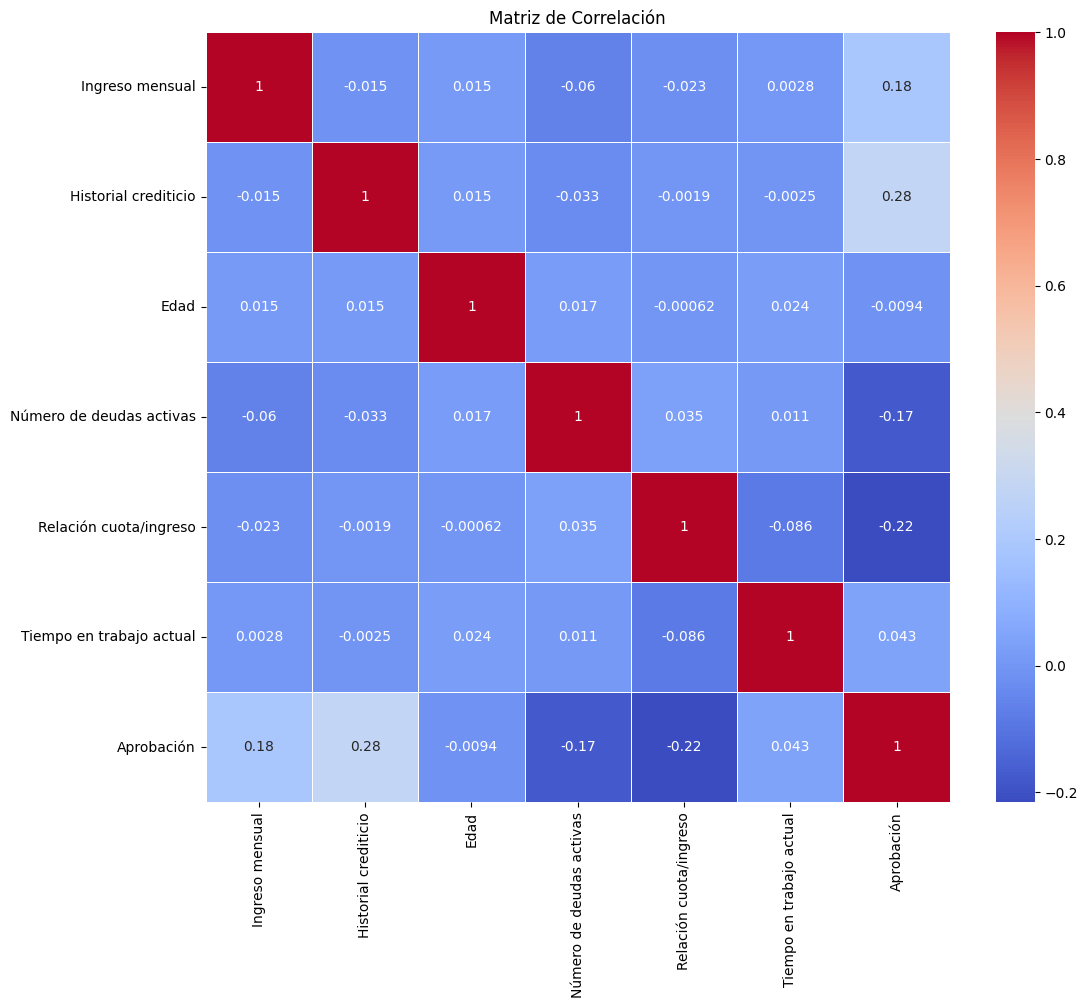

In [7]:
# Matriz de correlación
correlation_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

In [8]:
# Separación de características y variable objetivo
X = df.drop('Aprobación', axis=1)
y = df['Aprobación']

In [9]:
# División del conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  
print("tamaño de X_train_scaled:", X_train_scaled.shape)
print("tamaño de X_test_scaled:", X_test_scaled.shape)

tamaño de X_train_scaled: (800, 6)
tamaño de X_test_scaled: (200, 6)


In [11]:
# Definicion de la arquitectura de la red neuronal
model = Sequential([
    Dense(12, activation='relu', input_shape=(X_train_scaled.shape[1],), name='capaOculta1'),
    Dense(8, activation='relu', name='capaOculta2'),
    Dense(1, activation='sigmoid', name='capaSalida')
]) 

In [13]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 capaOculta1 (Dense)         (None, 12)                84        
                                                                 
 capaOculta2 (Dense)         (None, 8)                 104       
                                                                 
 capaSalida (Dense)          (None, 1)                 9         
                                                                 
Total params: 197 (788.00 Byte)
Trainable params: 197 (788.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [18]:
# Compilación del modelo
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [19]:
#entrenamiento del modelo
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1)
print("Entrenamiento completado.")

Epoch 1/50


20/20 [==============================] - 1s 14ms/step - loss: 0.7798 - accuracy: 0.4047 - val_loss: 0.7852 - val_accuracy: 0.3313
Epoch 2/50
20/20 [==============================] - 0s 4ms/step - loss: 0.7485 - accuracy: 0.4031 - val_loss: 0.7550 - val_accuracy: 0.3187
Epoch 3/50
20/20 [==============================] - 0s 4ms/step - loss: 0.7265 - accuracy: 0.4062 - val_loss: 0.7341 - val_accuracy: 0.3063
Epoch 4/50
20/20 [==============================] - 0s 4ms/step - loss: 0.7096 - accuracy: 0.4313 - val_loss: 0.7193 - val_accuracy: 0.3562
Epoch 5/50
20/20 [==============================] - 0s 4ms/step - loss: 0.6977 - accuracy: 0.4812 - val_loss: 0.7051 - val_accuracy: 0.4563
Epoch 6/50
20/20 [==============================] - 0s 4ms/step - loss: 0.6867 - accuracy: 0.5281 - val_loss: 0.6958 - val_accuracy: 0.5437
Epoch 7/50
20/20 [==============================] - 0s 4ms/step - loss: 0.6783 - accuracy: 0.5859 - val_loss: 0.6855 - val_accuracy: 0.6187
Epoch 8/50
20/20 

In [21]:
# Evaluación del modelo en el conjunto de prueba
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=1)
print(f"Loss en el conjunto de prueba: {test_loss}")
print(f"Accuracy en el conjunto de prueba: {test_accuracy}")

7/7 [==============================] - 0s 2ms/step - loss: 0.5917 - accuracy: 0.6750
Loss en el conjunto de prueba: 0.5917089581489563
Accuracy en el conjunto de prueba: 0.675000011920929
